for both classification and regression problems! KNN algorithm is by far more popularly used for classification problems, however. seldom seen KNN being implemented on any regression task. 

My aim here is to illustrate and emphasize how KNN can be equally effective when the target variable is continuous in nature.

In [ ]:
K-nn== K-nearest neighbours --- regression or classificatio -- supervised machine learning tecgnique

k-means -- clustering --- unsupervided machine learning technique

KNN algorithm can be used for both classification and regression problems. The KNN algorithm uses ‘feature similarity’ to predict the values of any new data points. This means that the new point is assigned a value based on how closely it resembles the points in the training set. 



### Methods of the calculating distance between points

The first step is to calculate the distance between the new point and each training point. There are various methods for calculating this distance, of which the most commonly known methods are – Euclidian, Manhattan (for continuous) and Hamming distance (for categorical).

Euclidean Distance: Euclidean distance is calculated as the square root of the sum of the squared differences between a new point (x) and an existing point (y).
Manhattan Distance: This is the distance between real vectors using the sum of their absolute difference.
Hamming Distance: It is used for categorical variables. If the value (x) and the value (y) are the same, the distance D will be equal to 0 . Otherwise D=1.


Once the distance of a new observation from the points in our training set has been measured, the next step is to pick the closest points. The number of points to be considered is defined by the value of k.

### How to choose the k factor?

This determines the number of neighbors we look at when we assign a value to any new observation.

K-Nearest Neighbors (KNN) regression is a machine learning algorithm used for predicting continuous variables. It works by finding the K nearest data points to a new input data point, and then using the average (or median) of the target variable values of those K data points as the predicted value for the new input point.

Here are the main steps involved in using a KNN regressor:

    Choose the value of K: K is the number of nearest neighbors to consider. This is typically chosen based on cross-validation or some other evaluation method.

    Calculate distances: Calculate the distance between the new input data point and all the existing data points in the dataset. Euclidean distance is commonly used, but other distance metrics can also be used.

    Identify the K nearest neighbors: Identify the K data points in the dataset that are closest to the new input data point based on the distance metric used.

    Calculate the predicted value: Take the average (or median) of the target variable values of the K nearest neighbors, and use this as the predicted value for the new input data point.

    Return the predicted value: Return the predicted value for the new input data point.

    KNN regressor is a simple and easy-to-understand algorithm, but it can be computationally expensive when dealing with large datasets. Additionally, the choice of K can have a significant impact on the performance of the model, and it may require some experimentation to find the optimal value of K for a given dataset.

In [ ]:

new data point is near by 1_point_dist = 0.1  --- y_value == 3735.1380
                            2nd_point_dist = 0.5 y_value = 443.4228
                            3rd_point = 0.9      y_value = 2097.2700
                            25th_point
                            56th_point
    new_data_point-- y_value === meanof(3735.1380+443.4228+2097.2700) == around 2090 is the predicte dvalue for new data point

entire_dataset size=100 rows

1_point_dist = 0.1
2nd_point_dist = 0.5
3rd_point = 0.9
4th_point = 1.5
-
-
-
-
100th point = 20.5



n_neighbors=5:
    

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('bigmartsales.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df['Outlet_Size'].value_counts()

Medium    2793
Small     2388
High       932
Name: Outlet_Size, dtype: int64

In [4]:
df.isnull().sum()
#missing values in Item_weight and Outlet_size needs to be imputed
mean = df['Item_Weight'].mean() #imputing item_weight with mean
df['Item_Weight'].fillna(mean, inplace =True)

mode = df['Outlet_Size'].mode() #imputing outlet size with mode
df['Outlet_Size'].fillna(mode[0], inplace =True)

In [5]:
df.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True)

df = pd.get_dummies(df)

In [6]:
from sklearn.model_selection import train_test_split
train , test = train_test_split(df, test_size = 0.3)

x_train = train.drop('Item_Outlet_Sales', axis=1)
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales', axis = 1)
y_test = test['Item_Outlet_Sales']

In [7]:
# only for features we applying feature scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

x_train_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train_scaled)

x_test_scaled = scaler.fit_transform(x_test)
x_test = pd.DataFrame(x_test_scaled)

In [8]:
x_test

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,0.460024,0.068078,0.687289,0.500000,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.671838,0.063901,0.044561,0.583333,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.448091,0.092744,0.489653,0.500000,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.176611,0.084782,0.515181,0.708333,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.298926,0.085284,0.968214,0.583333,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,0.633055,0.285765,0.837392,0.500000,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2553,0.510740,0.288524,0.536177,0.791667,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2554,0.370525,0.304581,0.178501,0.541667,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2555,0.141706,0.000000,0.543849,0.708333,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [9]:
#import required packages
from sklearn import neighbors
from sklearn.metrics import mean_squared_error 
from math import sqrt
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
model = neighbors.KNeighborsRegressor(n_neighbors = 9)
model.fit(x_train, y_train)  #fit the model
pred=model.predict(x_test)

In [11]:
rmse_val = [] #to store rmse values for different k
for K in range(20):
    K = K+1
    model = neighbors.KNeighborsRegressor(n_neighbors = K)

    model.fit(x_train, y_train)  #fit the model
    pred=model.predict(x_test) #make prediction on test set
    error = sqrt(mean_squared_error(y_test,pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 1550.5741810770007
RMSE value for k=  2 is: 1363.2389446914756
RMSE value for k=  3 is: 1290.2723125392183
RMSE value for k=  4 is: 1251.1114470476016
RMSE value for k=  5 is: 1236.5923617090145
RMSE value for k=  6 is: 1226.7501023591292
RMSE value for k=  7 is: 1211.284061271021
RMSE value for k=  8 is: 1214.3590907530759
RMSE value for k=  9 is: 1212.7927623636142
RMSE value for k=  10 is: 1216.5328399679445
RMSE value for k=  11 is: 1222.7026145664531
RMSE value for k=  12 is: 1222.8467636866924
RMSE value for k=  13 is: 1225.7479437221805
RMSE value for k=  14 is: 1228.646592377633
RMSE value for k=  15 is: 1234.3848912826022
RMSE value for k=  16 is: 1240.4472510689027
RMSE value for k=  17 is: 1245.6074476861527
RMSE value for k=  18 is: 1249.9487340896717
RMSE value for k=  19 is: 1254.2525026464236
RMSE value for k=  20 is: 1260.663885194086


<AxesSubplot:>

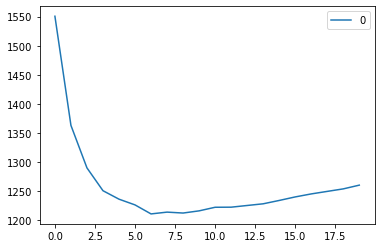

In [12]:
#plotting the rmse values against k values
curve = pd.DataFrame(rmse_val) #elbow curve 
curve.plot()

In [13]:
#reading test and submission files
test = pd.read_csv('bigmartsales_Test.csv')
#submission = pd.read_csv('SampleSubmission.csv')
submission = pd.DataFrame()
submission['Item_Identifier'] = test['Item_Identifier']
submission['Outlet_Identifier'] = test['Outlet_Identifier']

#preprocessing test dataset
test.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True)
test['Item_Weight'].fillna(mean, inplace =True)
test = pd.get_dummies(test)
test_scaled = scaler.fit_transform(test)
test = pd.DataFrame(test_scaled)

#predicting on the test set and creating submission file
predict = model.predict(test)
submission['Item_Outlet_Sales'] = predict
submission.to_csv('submit_file_for_kaggle.csv',index=False)

In [21]:
from sklearn.model_selection import GridSearchCV
params = {'n_neighbors':[2,3,4,5,6,7,8,9,10,11,12,13,14,15]}

knn = neighbors.KNeighborsRegressor()

model = GridSearchCV(knn, params, cv=3)
model.fit(x_train,y_train)
model.best_params_

{'n_neighbors': 9}